# 🌐 Challenge 3: Multilingual Toxic Comment Classification

**NeuroLogic '26: Global NLP Datathon**

---

## 📋 Task Overview
- Binary classification: Toxic (1) vs Non-toxic (0)
- Multilingual dataset (English + Hindi)
- Evaluation Metric: **ROC-AUC Score**

---

## 📦 Cell 1: Install Required Libraries

In [1]:
!pip install -q transformers datasets accelerate openpyxl scikit-learn pandas numpy matplotlib seaborn

## 📥 Cell 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Cell 3: Set File Paths

In [3]:
# File paths (upload files to /content/ directory in Colab)
TRAIN_PATH = '/content/toxic_labeled.xlsx'
TEST_PATH = '/content/toxic_no_label_evaluation.xlsx'

print("✅ File paths configured!")
print(f"📁 Training data: {TRAIN_PATH}")
print(f"📁 Test data: {TEST_PATH}")

✅ File paths configured!
📁 Training data: /content/toxic_labeled.xlsx
📁 Test data: /content/toxic_no_label_evaluation.xlsx


## 📊 Cell 4: Load and Explore Data

In [4]:
# Load datasets
train_df = pd.read_excel(TRAIN_PATH)
test_df = pd.read_excel(TEST_PATH)

print("📊 Training Data Shape:", train_df.shape)
print("📊 Test Data Shape:", test_df.shape)
print("\n" + "="*50)
print("\n📋 Training Data Columns:", train_df.columns.tolist())
print("\n" + "="*50)
print("\n🔍 First 5 rows of training data:")
print(train_df.head())
print("\n" + "="*50)
print("\n📈 Label Distribution:")
print(train_df['label'].value_counts())
print("\n" + "="*50)
print("\n📊 Missing Values:")
print(train_df.isnull().sum())

📊 Training Data Shape: (9000, 2)
📊 Test Data Shape: (1000, 2)


📋 Training Data Columns: ['text', 'label']


🔍 First 5 rows of training data:
                                                text  label
0  To everyone that became an eagle today. Congra...      0
1  राहुल गांधी की रैली में 95% लोग तो केवल ये देख...      1
2  देख लो ,ये अम्मा कांग्रेस की रजिस्टर्ड दुखियार...      1
3  We are straight but not blind best quote from ...      0
4  बोल तो ऐसे रहा है जैसे वो हल्दीघाटी का युद्ध ल...      1


📈 Label Distribution:
label
0    4506
1    4494
Name: count, dtype: int64


📊 Missing Values:
text     4
label    0
dtype: int64


## 📈 Cell 5: Data Visualization

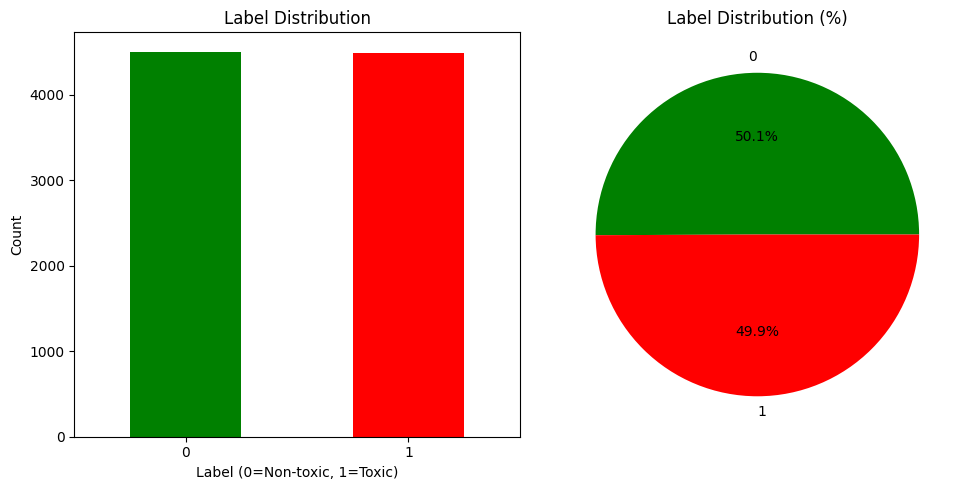

In [5]:
# Visualize label distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
train_df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Label Distribution')
plt.xlabel('Label (0=Non-toxic, 1=Toxic)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
train_df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Label Distribution (%)')
plt.ylabel('')

plt.tight_layout()
plt.show()

## 🔧 Cell 6: Data Preprocessing

In [6]:
# Identify text column (adjust if needed)
text_column = [col for col in train_df.columns if col != 'label'][0]
print(f"📝 Text column identified: {text_column}")

# Handle missing values
train_df[text_column] = train_df[text_column].fillna('')
test_df[text_column] = test_df[text_column].fillna('')

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    train_df[text_column],
    train_df['label'],
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

print(f"\n✅ Train size: {len(X_train)}")
print(f"✅ Validation size: {len(X_val)}")
print(f"✅ Test size: {len(test_df)}")

📝 Text column identified: text

✅ Train size: 7200
✅ Validation size: 1800
✅ Test size: 1000


## 🤖 Cell 7: Load Pre-trained Model (XLM-RoBERTa for Multilingual)

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

# Use multilingual model
MODEL_NAME = "xlm-roberta-base"  # Good for multilingual tasks

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

print(f"✅ Model loaded: {MODEL_NAME}")
print(f"✅ Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: xlm-roberta-base
✅ Device: cuda


## 🔄 Cell 8: Tokenize Data

In [8]:
from datasets import Dataset

# Create datasets
train_dataset = Dataset.from_dict({
    'text': X_train.tolist(),
    'label': y_train.tolist()
})

val_dataset = Dataset.from_dict({
    'text': X_val.tolist(),
    'label': y_val.tolist()
})

test_dataset = Dataset.from_dict({
    'text': test_df[text_column].tolist()
})

# Tokenization function
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

# Tokenize
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ Tokenization completed!")

Map:   0%|          | 0/7200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

✅ Tokenization completed!


## 📊 Cell 9: Define Metrics

In [9]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calculate probabilities for ROC-AUC
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    roc_auc = roc_auc_score(labels, probs)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc
    }

print("✅ Metrics defined!")

✅ Metrics defined!


## 🏋️ Cell 10: Training Configuration

In [10]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='roc_auc',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("✅ Trainer configured!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Trainer configured!


## 🚀 Cell 11: Train Model

In [11]:
print("🚀 Starting training...\n")
trainer.train()
print("\n✅ Training completed!")

🚀 Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc
1,0.315880,0.272481,0.911111,0.916840,0.860488,0.981090,0.980678
2,0.271347,0.228145,0.933889,0.936601,0.898773,0.977753,0.985067
3,0.177198,0.159157,0.956111,0.956570,0.945652,0.967742,0.987879


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Training completed!


## 📊 Cell 12: Evaluate on Validation Set

In [12]:
# Evaluate
eval_results = trainer.evaluate()

print("\n" + "="*50)
print("📊 VALIDATION RESULTS")
print("="*50)
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")
print("="*50)


📊 VALIDATION RESULTS
eval_loss: 0.1592
eval_accuracy: 0.9561
eval_f1: 0.9566
eval_precision: 0.9457
eval_recall: 0.9677
eval_roc_auc: 0.9879
eval_runtime: 3.0886
eval_samples_per_second: 582.7980
eval_steps_per_second: 18.4550
epoch: 3.0000


## 🔮 Cell 13: Generate Predictions for Test Set

In [13]:
# Predict on test set
predictions = trainer.predict(test_dataset)
logits = predictions.predictions
predicted_labels = np.argmax(logits, axis=-1)

# Add predictions to test dataframe
test_df['label'] = predicted_labels

print("✅ Predictions generated!")
print(f"\n📊 Predicted label distribution:")
print(test_df['label'].value_counts())
print("\n🔍 First 10 predictions:")
print(test_df.head(10))

✅ Predictions generated!

📊 Predicted label distribution:
label
1    524
0    476
Name: count, dtype: int64

🔍 First 10 predictions:
                                                text  label
0  सपना तो कोई भी देख सकता है चाहे कोई भी जाति या...      1
1  Anushka Sharma is one of the best. She is the ...      0
2  भारतीय शास्त्रीय संगीत के विश्वविख्यात नाम पंड...      0
3      Bet he biggest pussy ever wit no gun in hand.      1
4  बच्चे पैदा करते हैं कहते हैं अल्लाह की देन है ...      1
5  ऊसके मुंह में कटा हुआ जो ठुसा है।कैसे बोलेगा ह...      1
6   She's a piece of shit I hope she catches an STD.      1
7  Bitches have 20 abortions and want they pussy ...      1
8  बेहद भयावह स्थिति है! यह वायरल वीडियो पटना एम्...      1
9  California would be a better place without all...      1


## 💾 Cell 14: Save Predictions

In [14]:
# Save to Excel
output_path = '/content/no_label.xlsx'
test_df.to_excel(output_path, index=False)

print(f"✅ Predictions saved to: {output_path}")
print("\n⚠️ IMPORTANT: Make sure labels are 0 or 1 (not encoded differently)")
print(f"\n✅ Unique labels in submission: {test_df['label'].unique()}")

✅ Predictions saved to: /content/no_label.xlsx

⚠️ IMPORTANT: Make sure labels are 0 or 1 (not encoded differently)

✅ Unique labels in submission: [1 0]


## 📈 Cell 15: Visualize Results (Optional)

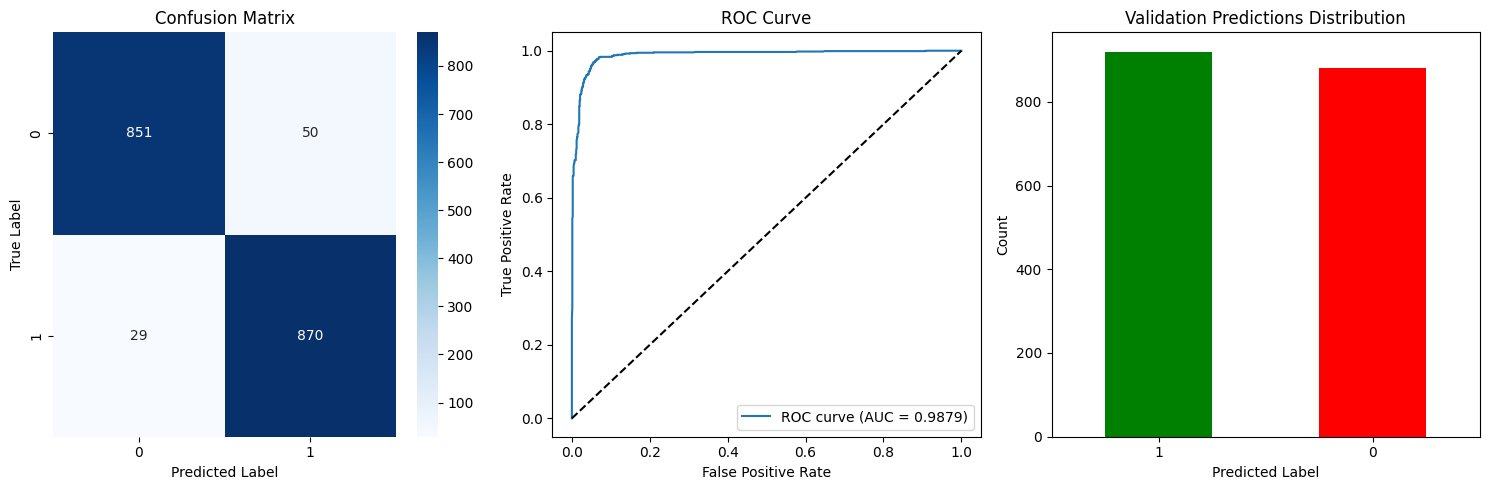


📊 Classification Report:
              precision    recall  f1-score   support

   Non-toxic       0.97      0.94      0.96       901
       Toxic       0.95      0.97      0.96       899

    accuracy                           0.96      1800
   macro avg       0.96      0.96      0.96      1800
weighted avg       0.96      0.96      0.96      1800



In [15]:
# Get validation predictions for visualization
val_predictions = trainer.predict(val_dataset)
val_logits = val_predictions.predictions
val_probs = torch.softmax(torch.tensor(val_logits), dim=-1)[:, 1].numpy()
val_preds = np.argmax(val_logits, axis=-1)

# Confusion Matrix
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_val, val_probs)
roc_auc = roc_auc_score(y_val, val_probs)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Prediction Distribution
plt.subplot(1, 3, 3)
pd.Series(val_preds).value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Validation Predictions Distribution')
plt.xlabel('Predicted Label')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Print classification report
print("\n📊 Classification Report:")
print(classification_report(y_val, val_preds, target_names=['Non-toxic', 'Toxic']))

## 📝 Cell 16: Summary and Next Steps

In [17]:
print("="*60)
print("🎉 CHALLENGE 3: MULTILINGUAL TOXIC CLASSIFICATION - COMPLETE")
print("="*60)
print(f"\n✅ Model: {MODEL_NAME}")
print(f"✅ Validation ROC-AUC: {eval_results['eval_roc_auc']:.4f}")
print(f"✅ Validation Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"✅ Validation F1-Score: {eval_results['eval_f1']:.4f}")
print(f"\n✅ Predictions saved to: {output_path}")


🎉 CHALLENGE 3: MULTILINGUAL TOXIC CLASSIFICATION - COMPLETE

✅ Model: xlm-roberta-base
✅ Validation ROC-AUC: 0.9879
✅ Validation Accuracy: 0.9561
✅ Validation F1-Score: 0.9566

✅ Predictions saved to: /content/no_label.xlsx
